In [131]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt



random_state = 18


In [ ]:
path = r'Mall_Customers.csv'
p = pd.read_csv(path)

df = pd.DataFrame(p)
df = df.drop('CustomerID', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [119]:
# One hot encode the 'Gender' column
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print(df.head())
print(df.info())

#Scale the features 

   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB
None


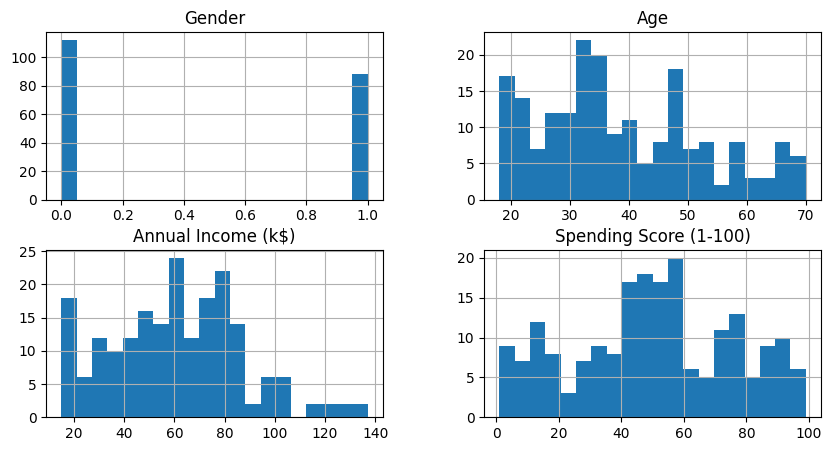

In [120]:

X= df 
X.hist(figsize=(10,5), bins=20)
plt.show()


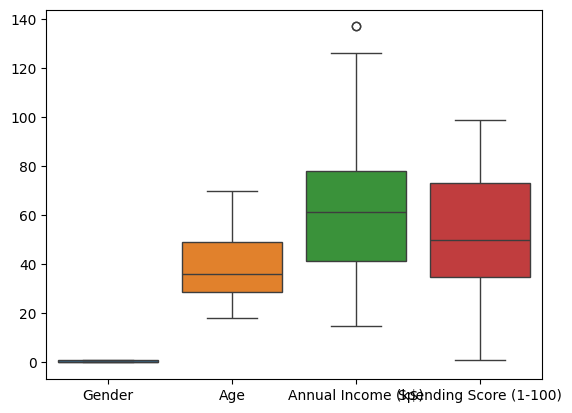

In [121]:
sns.boxplot(data=X)
plt.show()

In [122]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


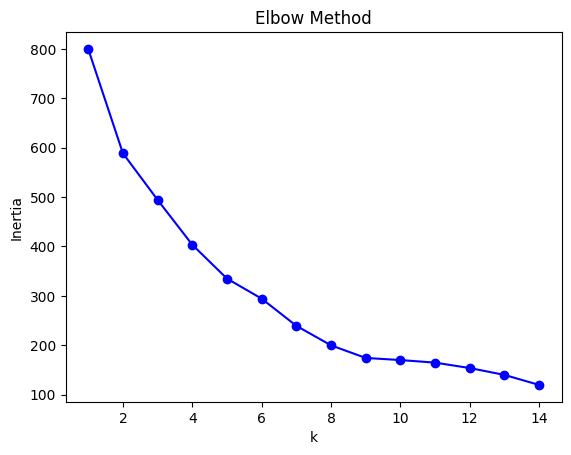

In [123]:
# determine the number of features 
# elbow method 

inertia = []
cluster_range = range(1, 15)
for cluster_num in cluster_range :
    kmeans = KMeans(n_clusters=cluster_num, random_state=random_state)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(cluster_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [124]:
from sklearn.metrics import silhouette_score

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette score={score:.2f}")

k=2, silhouette score=0.25
k=3, silhouette score=0.26
k=4, silhouette score=0.28
k=5, silhouette score=0.31
k=6, silhouette score=0.31
k=7, silhouette score=0.36
k=8, silhouette score=0.39
k=9, silhouette score=0.40
k=10, silhouette score=0.38
k=11, silhouette score=0.35
k=12, silhouette score=0.34
k=13, silhouette score=0.35
k=14, silhouette score=0.38
k=15, silhouette score=0.38
k=16, silhouette score=0.39
k=17, silhouette score=0.39
k=18, silhouette score=0.40
k=19, silhouette score=0.40


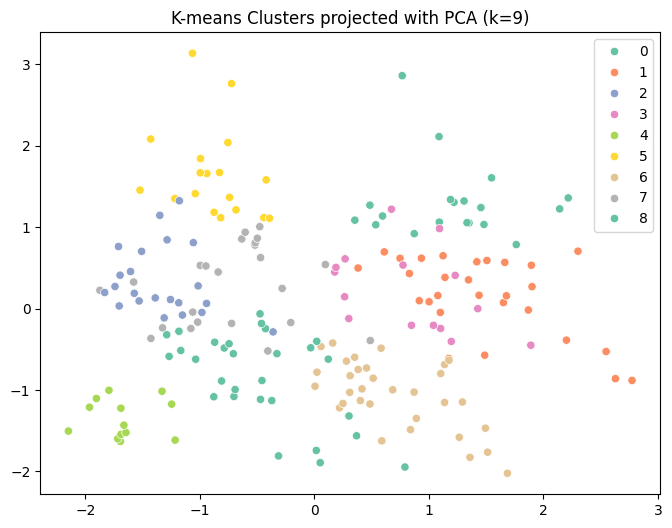

In [125]:
# k-means 
k= 9
kmeans = KMeans(n_clusters=k, random_state=random_state)
labels = kmeans.fit_predict(X)

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="Set2")
plt.title(f"K-means Clusters projected with PCA (k={k})")
plt.show()

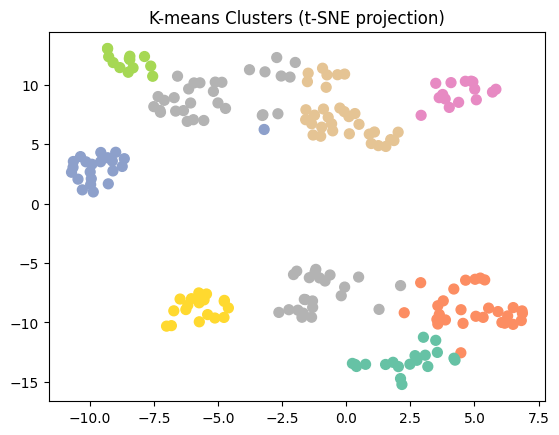

In [126]:
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=labels, cmap='Set2', s=50)
plt.title("K-means Clusters (t-SNE projection)")
plt.show()

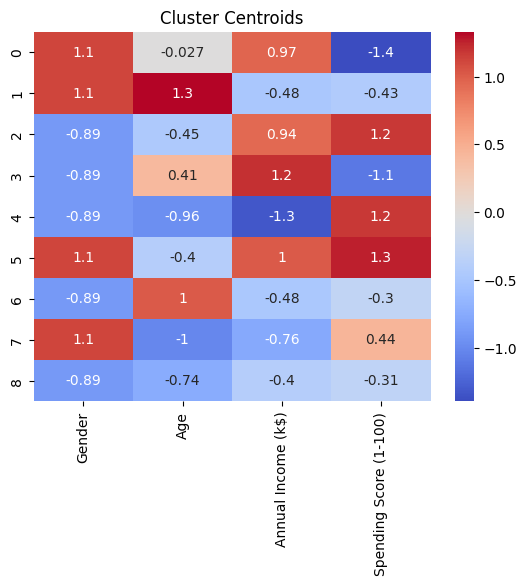

In [127]:
import pandas as pd
import seaborn as sns

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns)
sns.heatmap(centroids, annot=True, cmap="coolwarm")
plt.title("Cluster Centroids")
plt.show()

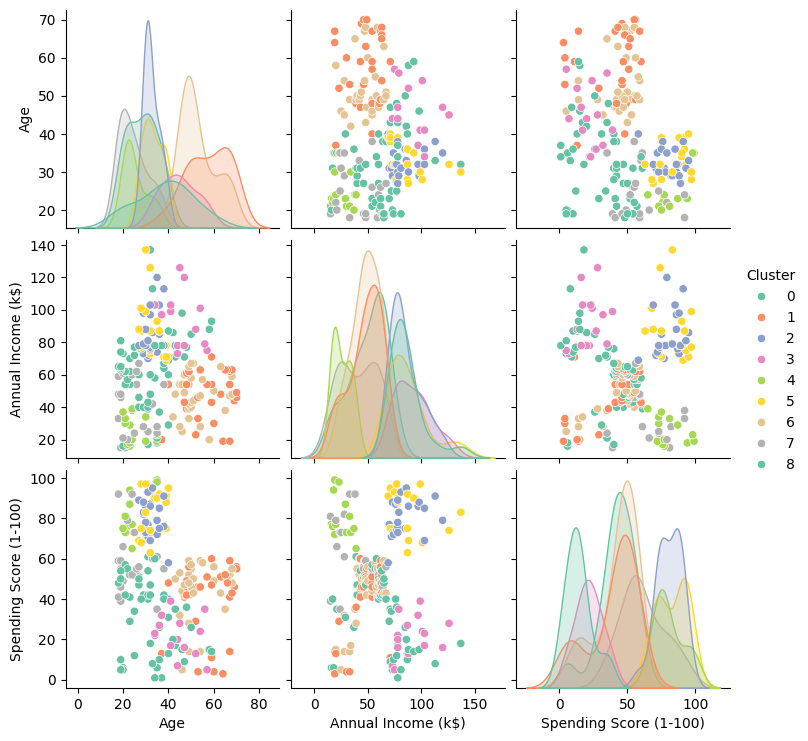

In [138]:
sns.pairplot(df[["Age","Annual Income (k$)","Spending Score (1-100)","Gender"]].assign(Cluster=labels),
             hue="Cluster", palette="Set2")
plt.show()

In [100]:
# 1. Instantiate the KMeans model with n_clusters=4
kmeans = KMeans(n_clusters=9, random_state=random_state, n_init=10) # n_init=10 is a common practice

# 2. Fit the model to the data
kmeans.fit(X)

# 3. Get the cluster labels and centroids
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster labels for the first 10 points:", cluster_labels[:5])
print("\nFinal centroids:\n", centroids)

Cluster labels for the first 10 points: [5 5 3 7 3]

Final centroids:
 [[-0.88640526 -0.45245636  0.94327069  1.17982252]
 [-0.88640526  0.41265847  1.21277    -1.11029664]
 [ 1.12815215 -0.02700694  0.96701244 -1.39716754]
 [-0.88640526 -0.76876973 -0.37148068 -0.29825668]
 [ 1.12815215 -0.39989994  1.01344075  1.26040667]
 [ 1.12815215 -0.97602698 -0.73705168  0.41603773]
 [-0.88640526  0.98505218 -0.49907107 -0.30892551]
 [-0.88640526 -0.96084556 -1.33087991  1.17778643]
 [ 1.12815215  1.37699013 -0.49354486 -0.44055282]]


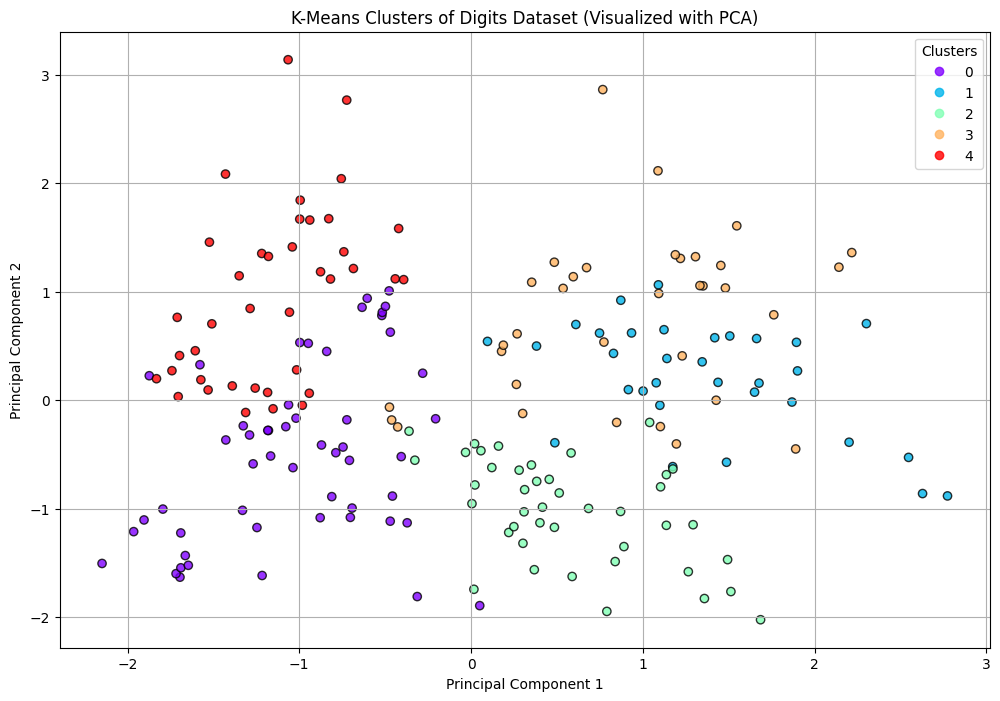

In [71]:
# --- 3. Reduce dimensions for VISUALIZATION using PCA ---
pca = PCA(n_components=2) # Reduce 64 dimensions to 2
X_pca = pca.fit_transform(X)

# X_pca now contains our data represented by 2 Principal Components
cluster_labels_hd = kmeans.fit_predict(X)

# --- 4. Visualize the results ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels_hd,
    cmap='rainbow',
    edgecolors='k',
    alpha=0.8
)

plt.title('K-Means Clusters of Digits Dataset (Visualized with PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.grid(True)
plt.show()